# Level-1: предсказание локальных исходов

Модели уровня 1 предсказывают **промежуточные** исходы матча на тех же признаках, что и Full pre-match бейзлайн. Цель - получить сигналы, которые захватывают разные грани матча и могут быть полезны Level-2 модели

### Таргеты

| # | Таргет | Тип | Группа | Смысл |
|---|---|---|---|---|
| 1 | `set1_winner_team1` | binary | раннее доминирование | команда 1 выиграла 1-й сет |
| 2 | `has_3rd_set` | binary | плотность | матч пошёл в 3 сета |
| 3 | `any_tiebreak` | binary | плотность | был тай-брейк хоть в одном сете |
| 4 | `set1_margin_games` | regression | раннее доминирование | разница геймов в 1-м сете |
| 5 | `games_diff_total` | regression | общее доминирование | суммарная разница геймов за матч |


### Схема обучения (expanding window по турнирам)

Перед каждым турниром 2024-2026 модели переобучаются на всей истории матчей до даты старта этого турнира:

```
для каждого турнира T из сортированного списка турниров 2024-2026:
    train = все матчи, played_at < T.start_date
    train_aug = swap-аугментация train
    predict = все матчи турнира T
```

Результат: `data/features/level1_predictions.csv`

In [14]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
from tqdm import tqdm

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.symmetry import augment_with_swap

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")
RAW = Path("../../data/raw")

matches = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
matches["year"] = matches["played_at"].dt.year

tournaments = pd.read_csv(RAW / "tournaments.csv", parse_dates=["start_date", "end_date"])
print(f"Матчей: {len(matches)}, турниров: {len(tournaments)}")


Матчей: 2549, турниров: 91


## Таргеты локальных исходов

In [16]:
matches["set1_winner_team1"] = (matches["set1_winner"] == "team_1").astype(int)
matches["has_3rd_set"] = (matches["n_sets"] >= 3).astype(int)

tb_cols = [
    "set1_tb_team1", "set1_tb_team2",
    "set2_tb_team1", "set2_tb_team2",
    "set3_tb_team1", "set3_tb_team2",
]
matches["any_tiebreak"] = matches[tb_cols].notna().any(axis=1).astype(int)

matches["set1_margin_games"] = matches["set1_team1"] - matches["set1_team2"]

games_diff = (
    (matches["set1_team1"].fillna(0) - matches["set1_team2"].fillna(0))
    + (matches["set2_team1"].fillna(0) - matches["set2_team2"].fillna(0))
    + (matches["set3_team1"].fillna(0) - matches["set3_team2"].fillna(0))
)
matches["games_diff_total"] = games_diff

valid = matches[
    matches["set1_winner"].isin(["team_1", "team_2"])
    & matches["set2_winner"].isin(["team_1", "team_2"])
].copy()
print(f"Завершённых матчей: {len(valid)} / {len(matches)}")

print("\nТаргеты:")
print(f"  set1_winner_team1    (bin): mean = {valid['set1_winner_team1'].mean():.3f}")
print(f"  has_3rd_set          (bin): mean = {valid['has_3rd_set'].mean():.3f}")
print(f"  any_tiebreak         (bin): mean = {valid['any_tiebreak'].mean():.3f}")
print(f"  set1_margin_games    (reg): mean = {valid['set1_margin_games'].mean():.2f}, std = {valid['set1_margin_games'].std():.2f}")
print(f"  games_diff_total     (reg): mean = {valid['games_diff_total'].mean():.2f}, std = {valid['games_diff_total'].std():.2f}")

Завершённых матчей: 2549 / 2549

Таргеты:
  set1_winner_team1    (bin): mean = 0.491
  has_3rd_set          (bin): mean = 0.279
  any_tiebreak         (bin): mean = 0.239
  set1_margin_games    (reg): mean = -0.06, std = 3.19
  games_diff_total     (reg): mean = -0.00, std = 5.79


## Сбор pre-match признаков (те же, что в Full бейзлайне)

In [17]:
blocks_files = {
    "rolling":        FEATURES / "rolling_stats.csv",
    "elo":            FEATURES / "elo.csv",
    "pair_chemistry": FEATURES / "pair_chemistry.csv",
    "h2h":            FEATURES / "head_to_head.csv",
    "form":           FEATURES / "form_and_streaks.csv",
    "rest":           FEATURES / "rest_and_load.csv",
    "context":        FEATURES / "context.csv",
    "matchup":        FEATURES / "matchup.csv",
}

le = LabelEncoder()
valid["tournament_level_enc"] = le.fit_transform(valid["tournament_level"].fillna("unknown"))
static_cols = ["round", "tournament_level_enc"]

TARGET_COLS = [
    "set1_winner_team1", "has_3rd_set", "any_tiebreak",
    "set1_margin_games", "games_diff_total",
]

data = valid[["match_id", "tournament_id", "played_at", "year"] + TARGET_COLS + static_cols].copy()

feat_cols = list(static_cols)
for name, p in blocks_files.items():
    b = pd.read_csv(p)
    data = data.merge(b, on="match_id", how="left")
    feat_cols += [c for c in b.columns if c != "match_id"]

# Категориальные (matchup): в int
str_cols = data.select_dtypes(include="object").columns.tolist()
for c in str_cols:
    data[c] = LabelEncoder().fit_transform(data[c].astype(str).fillna("nan"))

print(f"Всего фич: {len(feat_cols)}")

Всего фич: 594


## Expanding window: перечень турниров для предсказания

In [19]:
tournaments = tournaments[tournaments["status"] == "finished"].copy()
tournaments_to_predict = tournaments[tournaments["start_date"].dt.year.isin([2024, 2025, 2026])]
tournaments_to_predict = tournaments_to_predict.sort_values("start_date")
tournaments_to_predict = tournaments_to_predict[
    tournaments_to_predict["tournament_id"].isin(data["tournament_id"].unique())
]
print(f"Турниров для предиктов: {len(tournaments_to_predict)}")
print(tournaments_to_predict.groupby(tournaments_to_predict["start_date"].dt.year).size().rename("n_tournaments"))
print(tournaments_to_predict[["tournament_id", "name", "start_date"]].head())

Турниров для предиктов: 59
start_date
2024    27
2025    27
2026     5
Name: n_tournaments, dtype: int64
    tournament_id                                               name  \
8             117                     Riyadh Season Premier Padel P1   
9             120                  Ooredoo Qatar Major Premier Padel   
10            125                      Gnp Acapulco P1 Premier Padel   
11            127                    Puerto Cabello Premier Padel P2   
12            139  Lotto Brussels Premier Padel P2 Presented By B...   

   start_date  
8  2024-02-24  
9  2024-03-01  
10 2024-03-17  
11 2024-03-23  
12 2024-04-20  


## Обучение и построение прогнозов

In [20]:
TARGETS = {
    "set1_winner_team1":  "binary",
    "has_3rd_set":        "binary",
    "any_tiebreak":       "binary",
    "set1_margin_games":  "regression",
    "games_diff_total":   "regression",
}

SWAP_BINARY_INVERT = ("set1_winner_team1",)
SWAP_NEGATE = ("set1_margin_games", "games_diff_total")

XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)


def fit_model(train_df, features, target, kind):
    if kind == "binary":
        m = xgb.XGBClassifier(eval_metric="logloss", **XGB_PARAMS)
    else:
        m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(train_df[features], train_df[target], verbose=False)
    return m


def predict_model(model, df, features, kind):
    if kind == "binary":
        return model.predict_proba(df[features])[:, 1]
    return model.predict(df[features])


def out_col(target, kind):
    return f"prob_{target}" if kind == "binary" else f"pred_{target}"


preds = []
for _, t_row in tqdm(tournaments_to_predict.iterrows(), total=len(tournaments_to_predict)):
    tid = t_row["tournament_id"]
    t_start = t_row["start_date"]

    train_df = data[data["played_at"] < t_start]
    test_df = data[data["tournament_id"] == tid]
    if len(test_df) == 0 or len(train_df) < 100:
        continue

    train_aug = augment_with_swap(
        train_df,
        binary_invert_cols=SWAP_BINARY_INVERT,
        negate_cols=SWAP_NEGATE,
    )

    out = test_df[["match_id"]].copy()
    for target, kind in TARGETS.items():
        model = fit_model(train_aug, feat_cols, target, kind)
        out[out_col(target, kind)] = predict_model(model, test_df, feat_cols, kind)
    preds.append(out)

preds = pd.concat(preds, ignore_index=True)

  0%|          | 0/59 [00:00<?, ?it/s]/Users/yan/Desktop/HSE/HSE_Padel/src/symmetry.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["is_swapped"] = 1
  2%|▏         | 1/59 [00:03<03:28,  3.59s/it]/Users/yan/Desktop/HSE/HSE_Padel/src/symmetry.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["is_swapped"] = 1
  3%|▎         | 2/59 [00:07<03:28,  3.65s/it]/Users/yan/Desktop/HSE/HSE_Padel/src/symmetry.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

## Оценка Level-1

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_binary(y_true, y_prob):
    return {
        "accuracy": accuracy_score(y_true, (y_prob >= 0.5).astype(int)),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
    }


def evaluate_regression(y_true, y_pred):
    return {
        "mae":  mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2":   r2_score(y_true, y_pred),
    }


eval_df = preds.merge(data[["match_id", "year"] + list(TARGETS)], on="match_id")

bin_rows, reg_rows = [], []
sub = eval_df
for target, kind in TARGETS.items():
    col = out_col(target, kind)
    if kind == "binary":
        m = evaluate_binary(sub[target], sub[col])
    else:
        m = evaluate_regression(sub[target], sub[col])
    m.update({"target": target, "n": len(sub)})
    (bin_rows if kind == "binary" else reg_rows).append(m)

print("Бинарные таргеты:")
print(pd.DataFrame(bin_rows).set_index("target").round(3))
print("\nРегрессионные таргеты:")
print(pd.DataFrame(reg_rows).set_index("target").round(3))


Бинарные таргеты:
                        accuracy  roc_auc  log_loss  brier     n
year target                                                     
2024 set1_winner_team1     0.737    0.811     0.539  0.180  1057
     has_3rd_set           0.712    0.579     0.602  0.202  1057
     any_tiebreak          0.733    0.557     0.603  0.198  1057
2025 set1_winner_team1     0.727    0.802     0.551  0.184   992
     has_3rd_set           0.698    0.621     0.597  0.205   992
     any_tiebreak          0.785    0.575     0.525  0.170   992
2026 set1_winner_team1     0.736    0.804     0.549  0.182   174
     has_3rd_set           0.690    0.602     0.583  0.199   174
     any_tiebreak          0.655    0.447     0.707  0.248   174

Регрессионные таргеты:
                          mae   rmse     r2     n
year target                                      
2024 set1_margin_games  2.090  2.585  0.335  1057
     games_diff_total   3.359  4.229  0.478  1057
2025 set1_margin_games  2.114  2.615  0.316

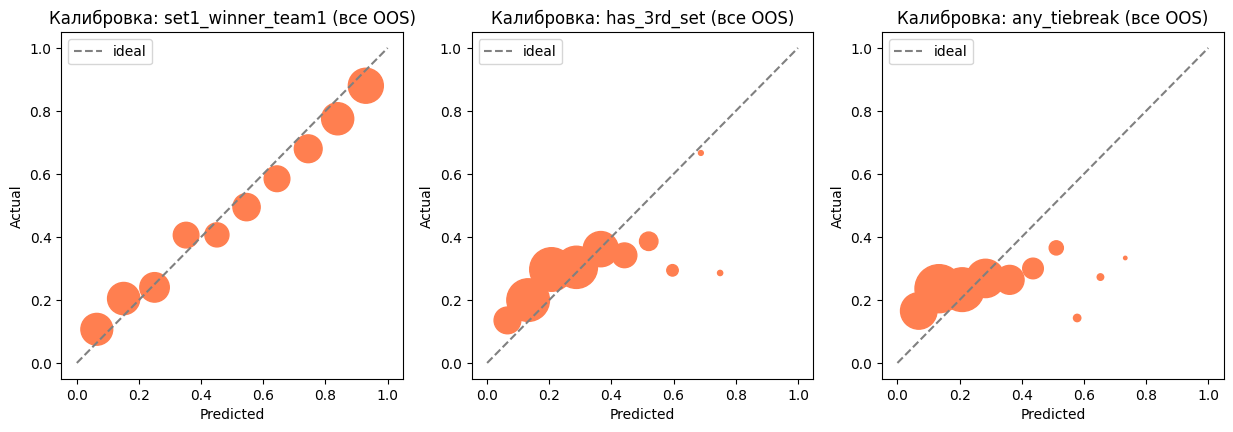

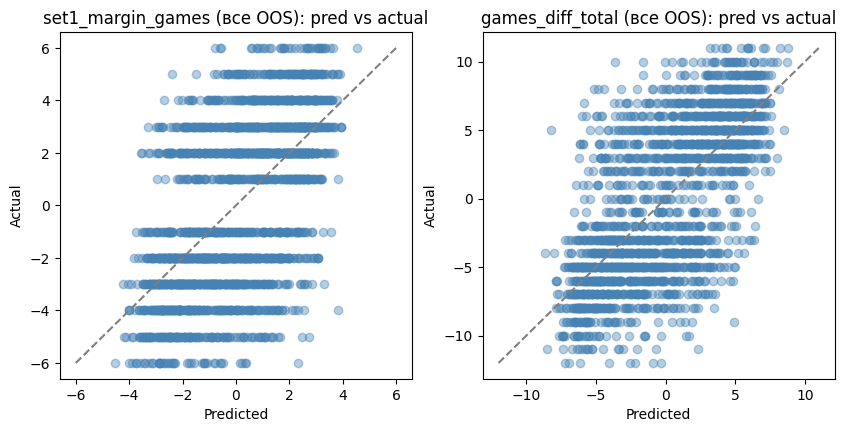

In [23]:
binary_targets = [t for t, k in TARGETS.items() if k == "binary"]
regression_targets = [t for t, k in TARGETS.items() if k == "regression"]

fig, axes = plt.subplots(1, len(binary_targets), figsize=(5 * len(binary_targets), 4.5))
for ax, target in zip(axes, binary_targets):
    sub = eval_df.copy()
    sub["bin"] = pd.cut(sub[f"prob_{target}"], bins=10)
    cal = sub.groupby("bin", observed=True).agg(
        predicted=(f"prob_{target}", "mean"),
        actual=(target, "mean"),
        count=(target, "size"),
    )
    ax.plot([0, 1], [0, 1], "--", color="gray", label="ideal")
    ax.scatter(cal["predicted"], cal["actual"], s=cal["count"] * 2, color="coral")
    ax.set_title(f"Калибровка: {target} (все OOS)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.legend()
plt.show()

fig, axes = plt.subplots(1, len(regression_targets), figsize=(5 * len(regression_targets), 4.5))
for ax, target in zip(axes, regression_targets):
    sub = eval_df
    ax.scatter(sub[f"pred_{target}"], sub[target], alpha=0.4, color="steelblue")
    lo = min(sub[target].min(), sub[f"pred_{target}"].min())
    hi = max(sub[target].max(), sub[f"pred_{target}"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="gray")
    ax.set_title(f"{target} (все OOS): pred vs actual")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.show()


## Паттерны игровой активности и локальные исходы

/Users/yan/Desktop/HSE/HSE_Padel/src/symmetry.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["is_swapped"] = 1


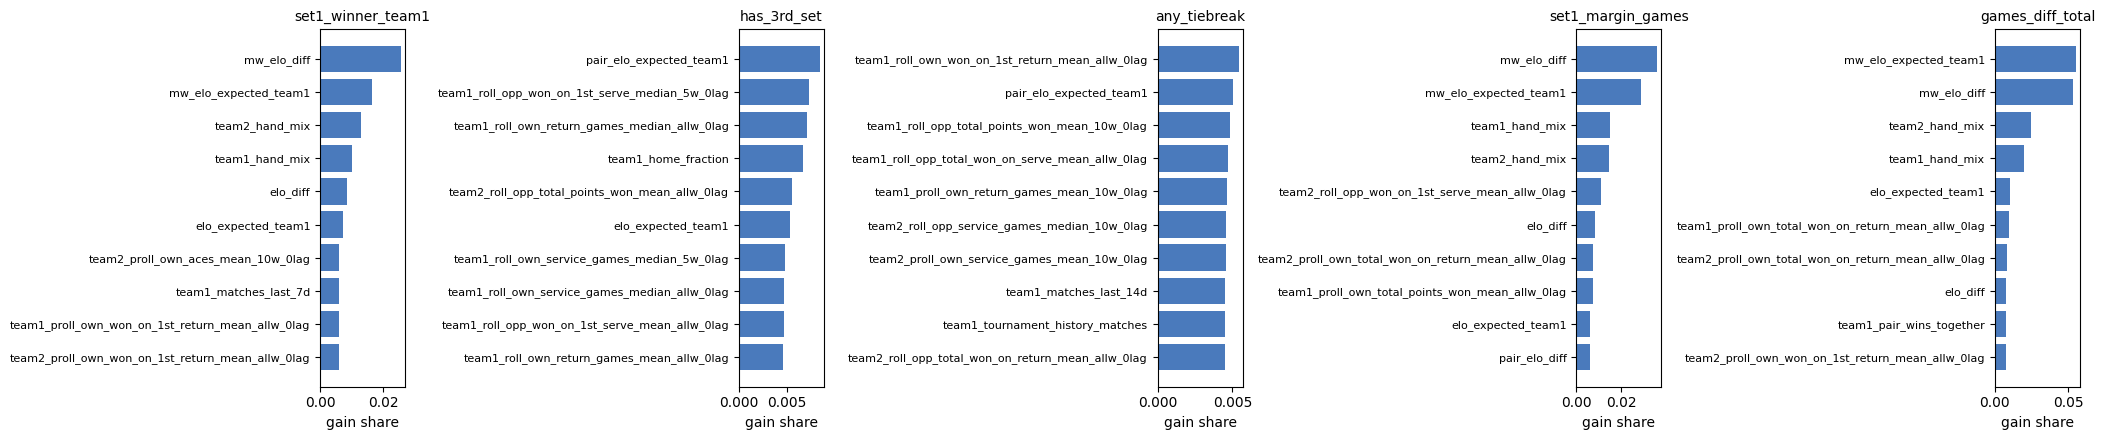


Топ-20 фич по gain share - set1_winner_team1:
mw_elo_diff                                           0.0257
mw_elo_expected_team1                                 0.0165
team2_hand_mix                                        0.0128
team1_hand_mix                                        0.0099
elo_diff                                              0.0085
elo_expected_team1                                    0.0071
team2_proll_own_aces_mean_10w_0lag                    0.0061
team1_matches_last_7d                                 0.0061
team1_proll_own_won_on_1st_return_mean_allw_0lag      0.0060
team2_proll_own_won_on_1st_return_mean_allw_0lag      0.0059
team1_proll_own_total_won_on_return_mean_allw_0lag    0.0058
team1_roll_own_return_games_median_allw_0lag          0.0052
team1_roll_opp_won_on_1st_serve_mean_allw_0lag        0.0051
team1_qoc_last10                                      0.0048
team2_roll_opp_total_won_on_return_median_5w_0lag     0.0048
team1_roll_opp_total_points_won_mean_1

In [28]:
train_all = data[data["played_at"] < pd.Timestamp("2025-01-01")]
train_all_aug = augment_with_swap(
    train_all,
    binary_invert_cols=SWAP_BINARY_INVERT,
    negate_cols=SWAP_NEGATE,
)

TOPK_PLOT = 10
TOPK_PRINT = 20
imp_rows = []
gain_full = {}
for target, kind in TARGETS.items():
    model = fit_model(train_all_aug, feat_cols, target, kind)
    booster = model.get_booster()
    score = booster.get_score(importance_type="gain")
    if score and next(iter(score)).startswith("f") and next(iter(score))[1:].isdigit():
        idx_to_feat = {f"f{i}": f for i, f in enumerate(feat_cols)}
        score = {idx_to_feat[k]: v for k, v in score.items()}
    gain = pd.Series(score).sort_values(ascending=False)
    gain = gain / gain.sum()
    gain_full[target] = gain
    for feat, share in gain.head(TOPK_PLOT).items():
        imp_rows.append({"target": target, "feature": feat, "gain_share": share})

imp_df = pd.DataFrame(imp_rows)

fig, axes = plt.subplots(1, len(TARGETS), figsize=(4.2 * len(TARGETS), 4.5))
for ax, target in zip(axes, TARGETS):
    sub = imp_df[imp_df["target"] == target].sort_values("gain_share")
    ax.barh(sub["feature"], sub["gain_share"], color="#4a7abc")
    ax.set_title(target, fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("gain share")
plt.tight_layout()
plt.show()

for target, gain in gain_full.items():
    print(f"\nТоп-{TOPK_PRINT} фич по gain share - {target}:")
    print(gain.head(TOPK_PRINT).round(4).to_string())

imp_df.to_csv(FEATURES / "level1_feature_importance.csv", index=False)


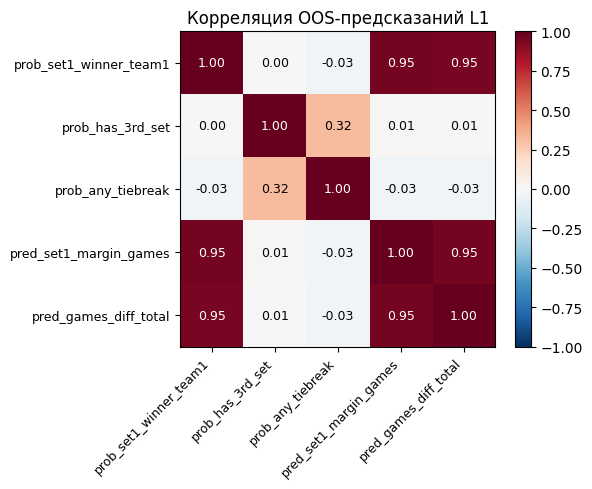

                        prob_set1_winner_team1  prob_has_3rd_set  \
prob_set1_winner_team1                   1.000             0.004   
prob_has_3rd_set                         0.004             1.000   
prob_any_tiebreak                       -0.025             0.318   
pred_set1_margin_games                   0.954             0.013   
pred_games_diff_total                    0.947             0.006   

                        prob_any_tiebreak  pred_set1_margin_games  \
prob_set1_winner_team1             -0.025                   0.954   
prob_has_3rd_set                    0.318                   0.013   
prob_any_tiebreak                   1.000                  -0.030   
pred_set1_margin_games             -0.030                   1.000   
pred_games_diff_total              -0.028                   0.954   

                        pred_games_diff_total  
prob_set1_winner_team1                  0.947  
prob_has_3rd_set                        0.006  
prob_any_tiebreak               

In [25]:
pred_cols = [out_col(t, k) for t, k in TARGETS.items()]
corr = preds[pred_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pred_cols))); ax.set_xticklabels(pred_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pred_cols))); ax.set_yticklabels(pred_cols, fontsize=9)
for i in range(len(pred_cols)):
    for j in range(len(pred_cols)):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iat[i, j]) > 0.6 else "black", fontsize=9)
ax.set_title("Корреляция OOS-предсказаний L1")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(corr.round(3))

## Сохранение

In [ ]:
out_path = FEATURES / "level1_predictions.csv"
preds.to_csv(out_path, index=False)

Сохранено: ../../data/features/level1_predictions.csv (2196 строк, 5 предсказаний)
Колонки: ['prob_set1_winner_team1', 'prob_has_3rd_set', 'prob_any_tiebreak', 'pred_set1_margin_games', 'pred_games_diff_total']
